In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os,shutil
import cv2
import matplotlib.image as mping
%matplotlib inline
plt.style.use('ggplot')
import seaborn as sns

In [4]:
import zipfile
z=zipfile.ZipFile('archive (4).zip')
z.extractall()

In [5]:
labels = ['PNEUMONIA','NORMAL']
img_size = 128
def get_data(data_dir):
    data = []
    labels_list = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append(resized_arr)  # Append only the image
                labels_list.append(class_num)  # Append only the label
            except Exception as e:
                print(e)
    return np.array(data), np.array(labels_list)

In [6]:
train=get_data('chest_xray/chest_xray/train')
test=get_data('chest_xray/chest_xray/test')
val=get_data('chest_xray/chest_xray/val')

In [7]:
pneumonia = os.listdir("chest_xray/train/PNEUMONIA")
penomina_dir = "chest_xray/train/PNEUMONIA"

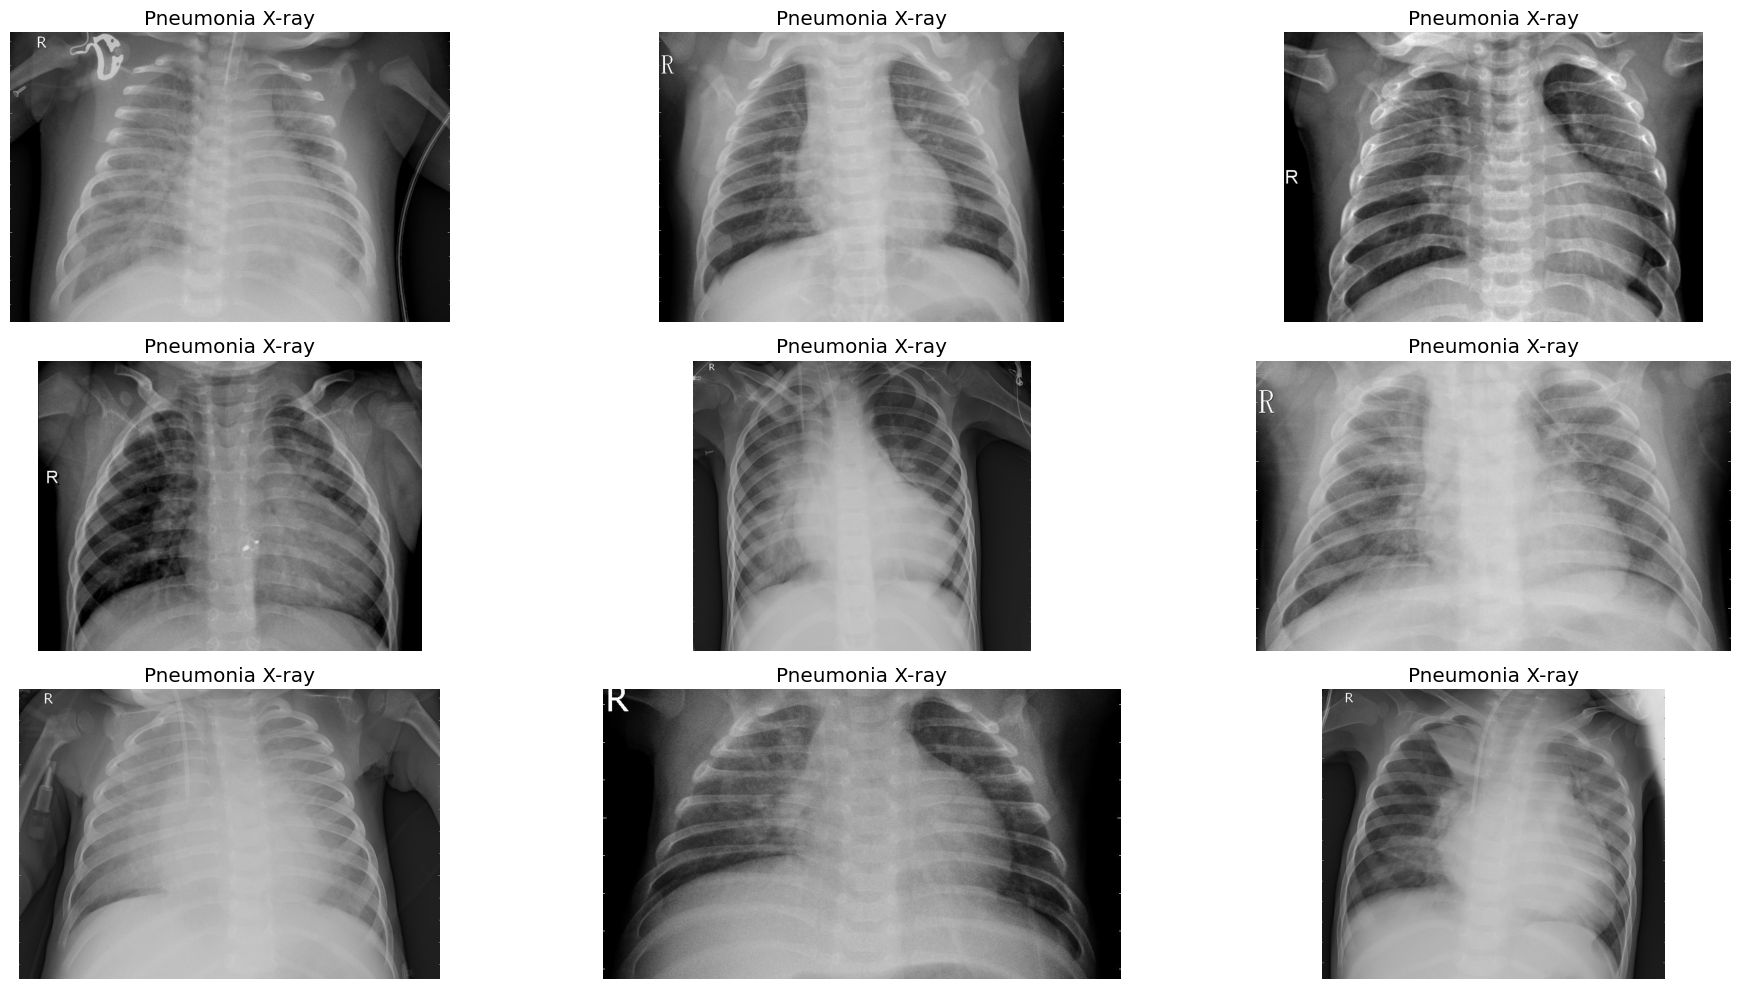

In [8]:
plt.figure(figsize=(20,10))

for i in range(9):
    plt.subplot(3,3, i+1)
    img = plt.imread(os.path.join(penomina_dir, pneumonia[i]))
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Pneumonia X-ray")
plt.tight_layout()

In [9]:
normal = os.listdir("chest_xray/train/NORMAL")
normal_dir = "chest_xray/train/NORMAL"

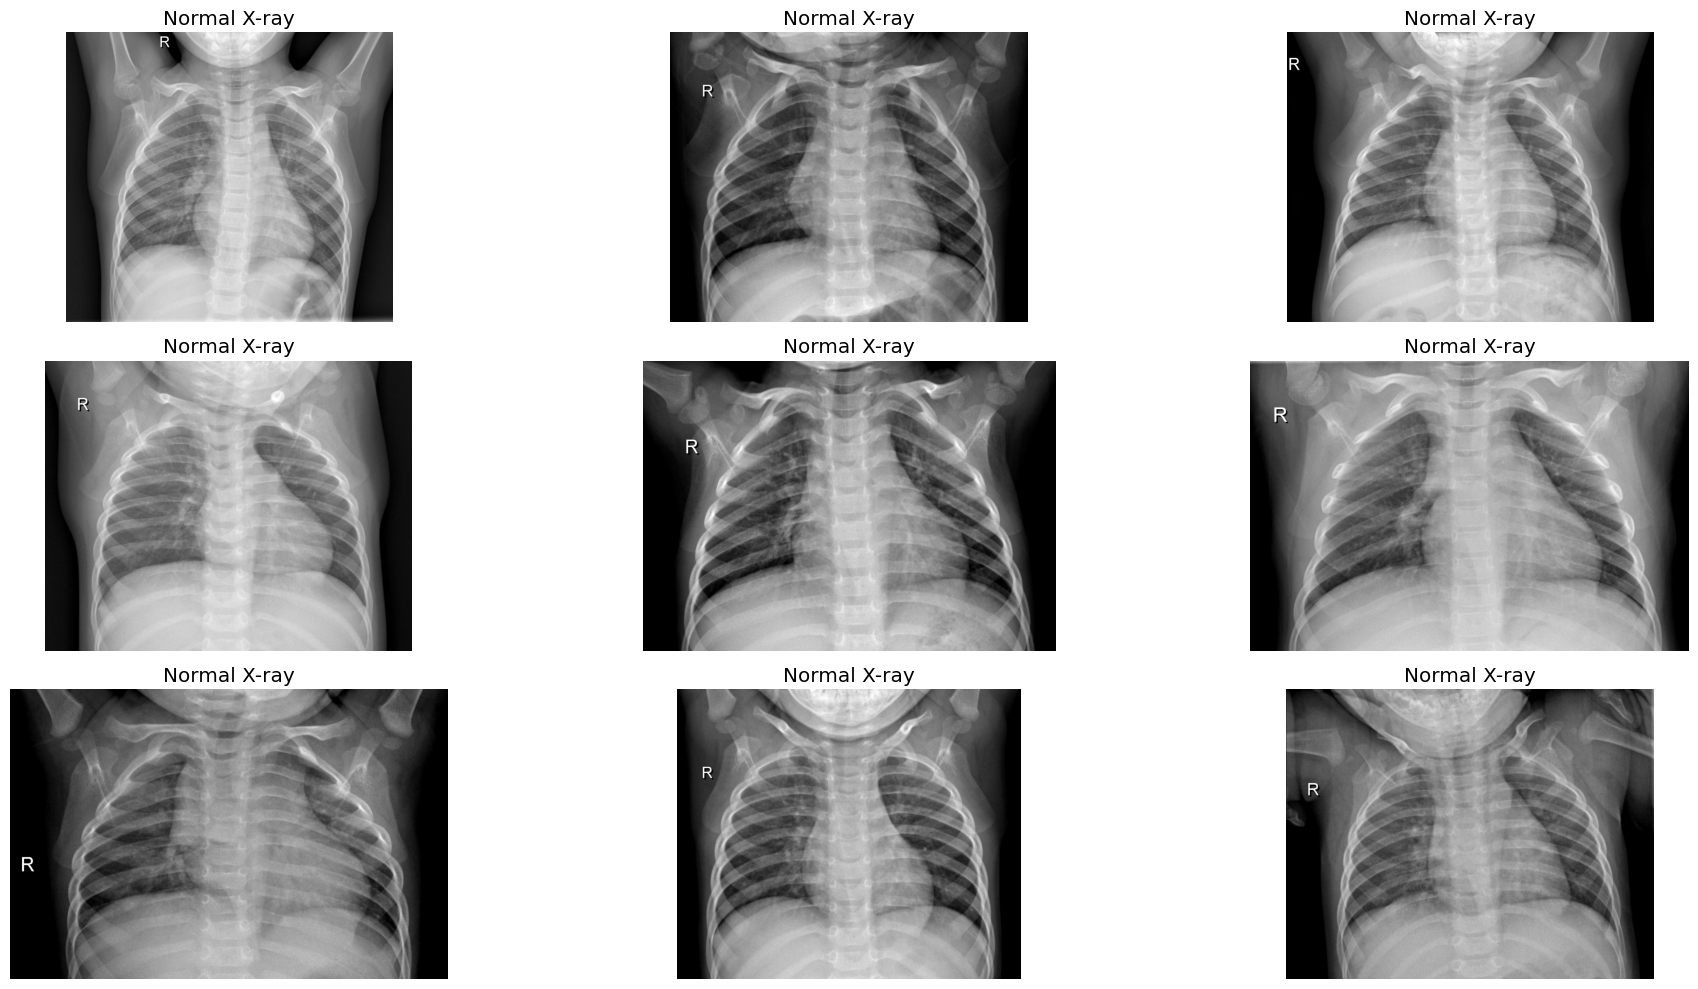

In [10]:
plt.figure(figsize=(20,10))

for i in range(9):
    plt.subplot(3,3, i+1)
    img = plt.imread(os.path.join(normal_dir, normal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title("Normal X-ray")
plt.tight_layout()

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [29]:
# Data Augmentation for the Training Set
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  
    rotation_range=10,  
    width_shift_range=0.1,  
    height_shift_range=0.1,  
    shear_range=0.1,  
    zoom_range=0.1,  
    horizontal_flip=True,  
    fill_mode='nearest'
)

# Validation and Test sets should only be normalized
val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load data using flow_from_directory
train_gen = train_datagen.flow_from_directory(
    'chest_xray/chest_xray/train',
    target_size=(img_size, img_size),
    batch_size=64,
    class_mode='binary'  
)

val_gen = val_test_datagen.flow_from_directory(
    'chest_xray/chest_xray/val',
    target_size=(img_size, img_size),
    batch_size=64,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    'chest_xray/chest_xray/test',
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary',
    shuffle=False  
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the CNN model
model = Sequential()

model.add(Conv2D(32, (3, 3), padding="same", input_shape=(img_size, img_size, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.5))

model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation="relu"))

model.add(Dense(1))
model.add(Activation("sigmoid"))

callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=4, restore_best_weights=True)
opt = tf.keras.optimizers.Adam(learning_rate=1e-5)

In [35]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 activation_10 (Activation)  (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 64, 64, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_9 (Dropout)         (None, 64, 64, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 activation_11 (Activation)  (None, 64, 64, 64)        0         
                                                      

In [36]:

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


In [37]:
history = model.fit( train_gen,
    validation_data=val_gen,
    epochs=20, shuffle=True, callbacks=[callback])


Epoch 1/20
82/82 [==============================] - 100s 1s/step - loss: 0.6456 - accuracy: 0.7285 - val_loss: 0.7157 - val_accuracy: 0.5000
Epoch 2/20
82/82 [==============================] - 99s 1s/step - loss: 0.5150 - accuracy: 0.7429 - val_loss: 0.7087 - val_accuracy: 0.5000
Epoch 3/20
82/82 [==============================] - 108s 1s/step - loss: 0.3220 - accuracy: 0.8313 - val_loss: 0.8395 - val_accuracy: 0.6250
Epoch 4/20
82/82 [==============================] - 104s 1s/step - loss: 0.2660 - accuracy: 0.8817 - val_loss: 0.9428 - val_accuracy: 0.6250
Epoch 5/20
82/82 [==============================] - 105s 1s/step - loss: 0.2281 - accuracy: 0.9053 - val_loss: 0.5598 - val_accuracy: 0.7500
Epoch 6/20
82/82 [==============================] - 101s 1s/step - loss: 0.2246 - accuracy: 0.9091 - val_loss: 0.6627 - val_accuracy: 0.6875
Epoch 7/20
82/82 [==============================] - 102s 1s/step - loss: 0.2023 - accuracy: 0.9176 - val_loss: 0.8059 - val_accuracy: 0.7500
Epoch 8/20
82/

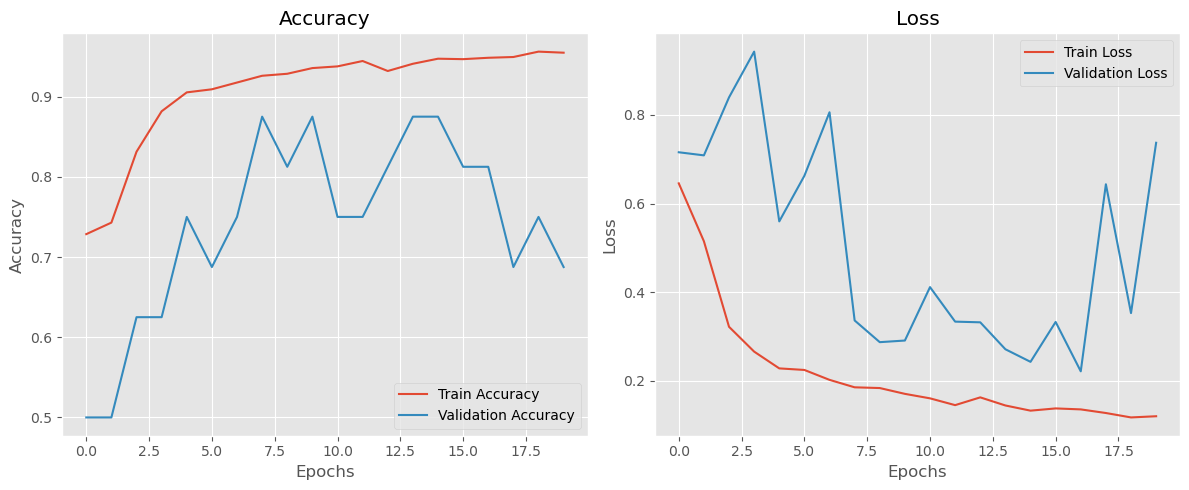

In [39]:
# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 79ms/step


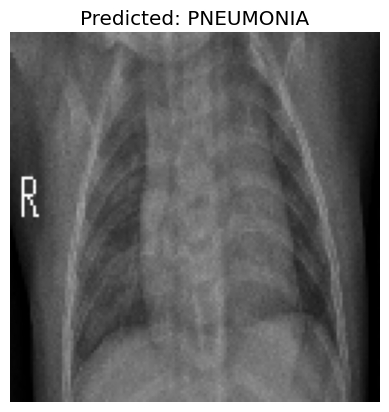

In [41]:
# Load a sample image from the test set
import random

test_images, _ = test_gen.next()  # Get a batch of test images
random_idx = random.randint(0, len(test_images) - 1)  # Pick a random image
sample_image = test_images[random_idx]

# Predict
sample_prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_label = "PNEUMONIA" if sample_prediction > 0.5 else "NORMAL"

# Visualize
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()


In [52]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [53]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

for layer in base_model.layers:
    layer.trainable = False

In [54]:
model = Sequential()
model.add(base_model)
model.add(Flatten())

# Add dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [55]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_5 (Flatten)         (None, 8192)              0         
                                                                 
 dense_11 (Dense)            (None, 256)               2097408   
                                                                 
 dropout_15 (Dropout)        (None, 256)               0         
                                                                 
 dense_12 (Dense)            (None, 128)               32896     
                                                                 
 dropout_16 (Dropout)        (None, 128)               0         
                                                                 
 dense_13 (Dense)            (None, 1)                

In [58]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
82/82 [==============================] - 358s 4s/step - loss: 0.1499 - accuracy: 0.9475 - val_loss: 0.2280 - val_accuracy: 0.8750
Epoch 2/10
82/82 [==============================] - 359s 4s/step - loss: 0.1358 - accuracy: 0.9502 - val_loss: 0.2828 - val_accuracy: 0.8125
Epoch 3/10
82/82 [==============================] - 233s 3s/step - loss: 0.1329 - accuracy: 0.9490 - val_loss: 0.2268 - val_accuracy: 0.8750
Epoch 4/10
82/82 [==============================] - 218s 3s/step - loss: 0.1305 - accuracy: 0.9513 - val_loss: 0.1758 - val_accuracy: 0.8750
Epoch 5/10
82/82 [==============================] - 283s 3s/step - loss: 0.1262 - accuracy: 0.9528 - val_loss: 0.2087 - val_accuracy: 0.8750
Epoch 6/10
82/82 [==============================] - 198s 2s/step - loss: 0.1170 - accuracy: 0.9582 - val_loss: 0.1785 - val_accuracy: 0.8750
Epoch 7/10
82/82 [==============================] - 145s 2s/step - loss: 0.1176 - accuracy: 0.9584 - val_loss: 0.1767 - val_accuracy: 0.8750
Epoch 8/10
82

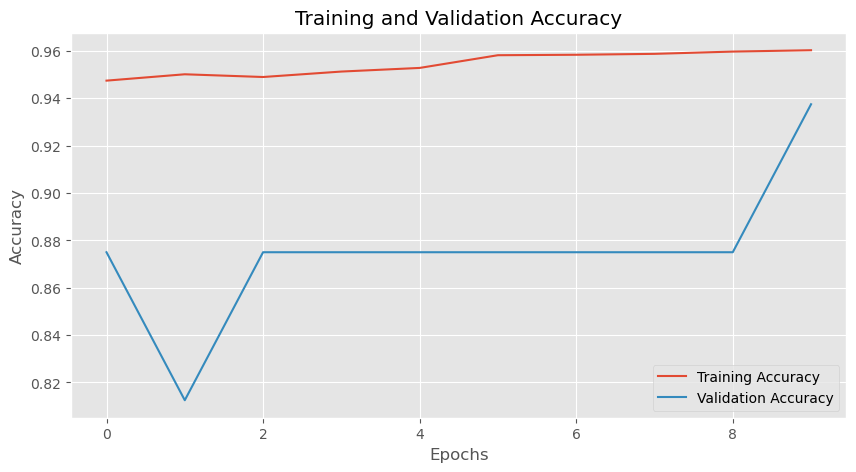

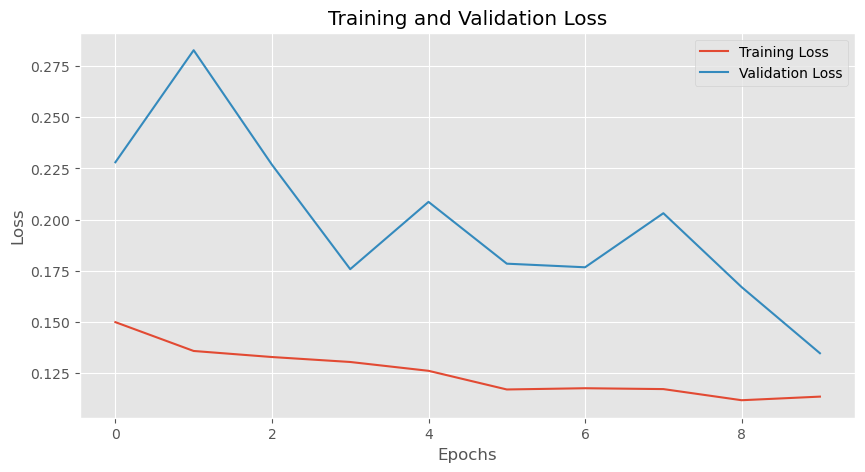

In [60]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

  

20/20 [==============================] - 15s 710ms/step


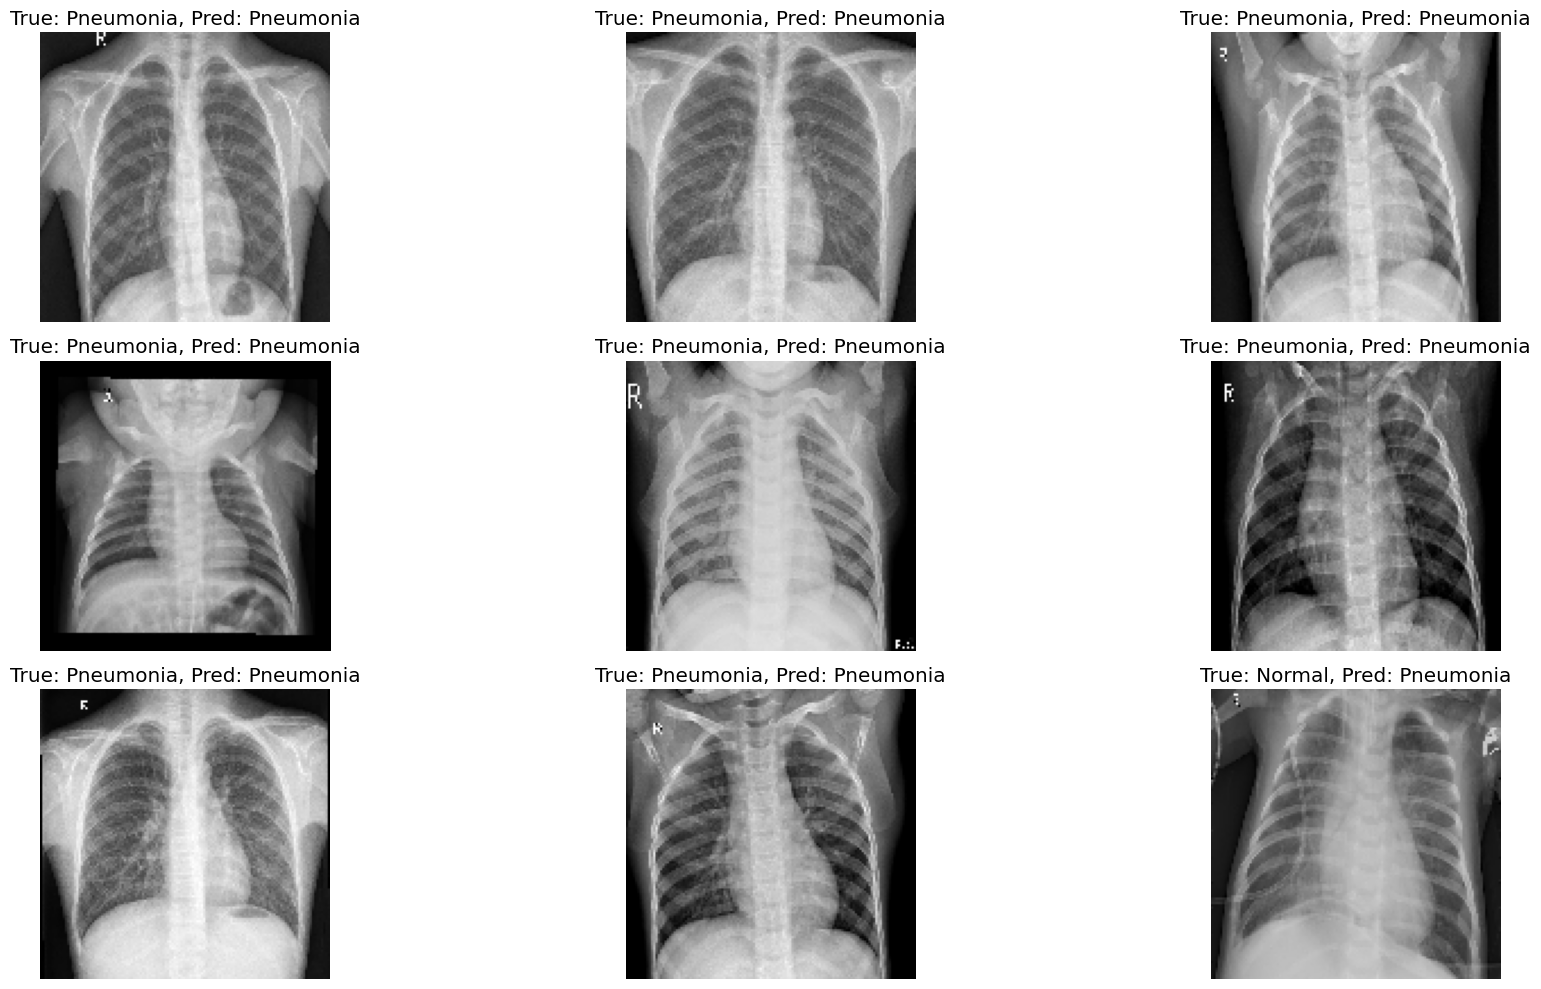

In [61]:
# Generate predictions
predictions = model.predict(test_gen)
predictions = (predictions > 0.5).astype(int)  

# Visualize predictions
plt.figure(figsize=(20, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    img, label = test_gen[i][0][0], test_gen[i][1][0]  # Get image and label
    plt.imshow(img)
    pred_label = 'Pneumonia' if predictions[i] == 0 else 'Normal'
    true_label = 'Pneumonia' if label == 0 else 'Normal'
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [62]:
import os

# Create a directory if it doesn't exist
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")

# Save the entire model
model.save(filepath="model_weights/vgg_unfrozen.h5", overwrite=True)
print("Model saved successfully as 'vgg_unfrozen.h5'")


C:\Users\91807\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully as 'vgg_unfrozen.h5'


In [63]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model("model_weights/vgg_unfrozen.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [64]:
print(train_gen.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}
